<a href="https://colab.research.google.com/github/AKookani/BrickwallCliffordCircuit/blob/main/Meeting_24_6_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stabilizer Formalism & Clifford Circuits

In [ ]:
!pip install qiskit ipywidgets
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=1256383917527b6f2481faf33927051dfe0808f0f29653d93e54e55b7889945b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


## Explanation of Qiskit stablizer

`qiskit.quantum_info.StabilizerState` represents a **stabilizer quantum state** in Qiskit.

A stabilizer state is any quantum state that can be fully described by **Pauli stabilizers** instead of a full statevector. This makes operations on Clifford circuits very efficient.

Typical examples:

* $|0\rangle$
* $|+\rangle$
* Bell states

### Example 1: Create $|0\rangle$ stabilizer

In [ ]:
from qiskit.quantum_info import StabilizerState, Statevector, SparsePauliOp

stabilizer_state = StabilizerState.from_stabilizer_list(["Z"]) #returns the state is stabilized by Z operator
print(stabilizer_state)

StabilizerState(['+Z'])


Here, `"Z"` means the state is stabilized by the Pauli (Z) operator:

$Z|0\rangle = |0\rangle$

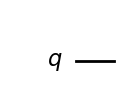

In [ ]:
Clifford_circuit = stabilizer_state.clifford.to_circuit()
display(Clifford_circuit.draw('mpl'))

.clifford means What Clifford tableau internally represents this stabilizer state?

In [ ]:
psi = Statevector.from_instruction(Clifford_circuit)
display(psi.draw('latex'))

<IPython.core.display.Latex object>

- **`Clifford`** — represents a Clifford *operation* (unitary). Internally it stores a tableau (symplectic matrix + phases) describing how that operation conjugates each Pauli generator. There's no "Clifford state" — `Clifford` is always an operator, never a state.
- **`StabilizerState`** — represents a stabilizer *state*. Internally it stores a `Clifford` object as its underlying data structure, but interprets it as: "the state obtained by applying this Clifford to $|0\rangle^{\otimes n}$." So a `StabilizerState`'s tableau is literally "what Pauli generators does $|0\rangle^{\otimes n}$ get mapped to" — i.e. the stabilizer generators of the resulting state.

In [ ]:
psi = Statevector.from_label('0')
print(psi.expectation_value(SparsePauliOp('Z')))

(1+0j)


In [ ]:
psi = Statevector.from_label('1')
print(psi.expectation_value(SparsePauliOp('Z')))

(-1+0j)


In [ ]:
psi = Statevector.from_label('+')
print(psi.expectation_value(SparsePauliOp('Z')))

0j


### Example 2: Bell state

The Bell state

[
$\frac{|00\rangle + |11\rangle}{\sqrt2}$
]

is stabilized by

* (XX)
* (ZZ)

In [ ]:
from qiskit.quantum_info import StabilizerState

bell = StabilizerState.from_stabilizer_list([
    "XX",
    "ZZ"
])

print(bell)

StabilizerState(['+XX', '+ZZ'])


### Example 3: From a Clifford circuit

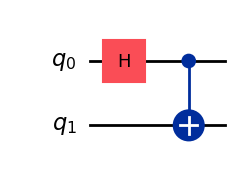

StabilizerState(['+XX', '+ZZ'])


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
display(qc.draw('mpl'))

state = StabilizerState(qc)
print(state)

## Stabilizer State Efficiency

**When to use Stabilizer State**

Use `StabilizerState` when your circuit only contains **Clifford gates**, such as:

* H
* S
* X, Y, Z
* CNOT (CX)
* SWAP

It is **much more memory-efficient** than a full statevector for these circuits.

If your circuit contains non-Clifford gates like `T`, `CCX` (Toffoli, in general), or arbitrary rotations (`RX`, `RY`, `RZ` with arbitrary angles), then `StabilizerState` is generally not applicable, and you'd instead use something like `Statevector`.

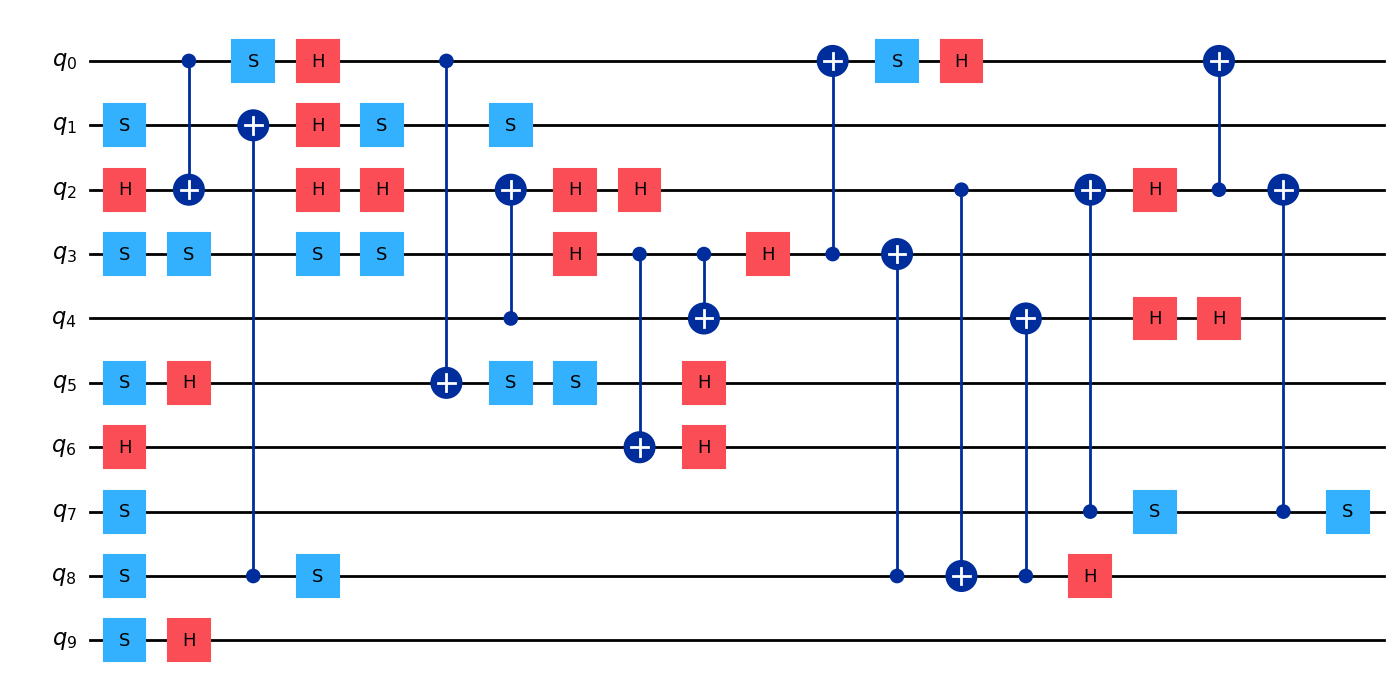

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState
import random

n = 10
qc = QuantumCircuit(n)

for _ in range(50):
    gate = random.choice(["h", "s", "cx"])

    if gate == "h":
        qc.h(random.randrange(n))

    elif gate == "s":
        qc.s(random.randrange(n))

    else:
        a, b = random.sample(range(n), 2)
        qc.cx(a, b)

qc.draw("mpl")

In [ ]:
stab = StabilizerState(qc)

print(stab) #There will be 10 generators because we have 10 qubits.

StabilizerState(['+IIZIZIIZIY', '-IXZIIIIXXX', '+IZZIIXIZII', '+IXZZIXZXIX', '-IXZIIZXZIY', '-IIIIZIIIII', '+IIIZIIIIII', '+IIZIIIIIII', '+IXZIIIIXIX', '+XIIIIIIIII'])


In [ ]:
from qiskit.quantum_info import Statevector

psi = Statevector.from_instruction(qc)

psi.draw('latex')

<IPython.core.display.Latex object>

# Measurement-induced dynamics in **Clifford circuits** using the **stabilizer formalism**

**Projective measurements** simulation on **random Clifford ciruits** to measure **entanglement entropy** and **purification time**.

In [ ]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.5 MB/s eta 0:00:00


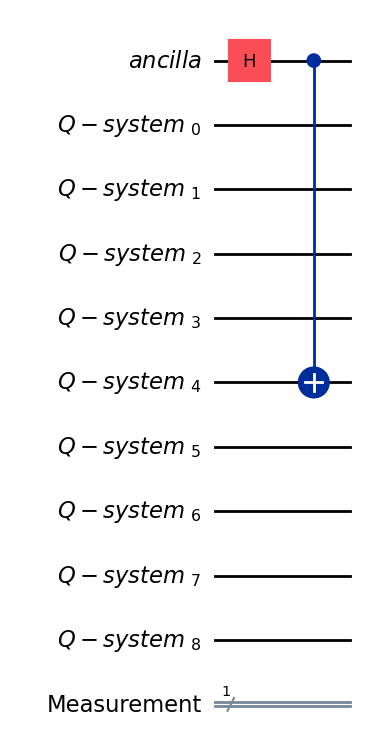

StabilizerState(['+IIIIXIIIIX', '+IIIIIIIIZI', '+IIIIIIIZII', '+IIIIIIZIII', '+IIIIIZIIII', '+IIIIZIIIIZ', '+IIIZIIIIII', '+IIZIIIIIII', '+IZIIIIIIII', '+ZIIIIIIIII'])


In [ ]:
from qiskit.quantum_info import StabilizerState
from qiskit import QuantumRegister, ClassicalRegister

size = 9 # systems_size

Ancilla = QuantumRegister(1, 'ancilla ')
System = QuantumRegister(size, 'Q-system ')
Measure = ClassicalRegister(1, "Measurement")

qc_base = QuantumCircuit(Ancilla, System, Measure)

qc_base.h(Ancilla)
qc_base.cx(Ancilla, System[size // 2])
display(qc_base.draw('mpl'))

state = StabilizerState(qc_base)

print(state)

StabilizerState(['+IIIIXIIIIX', '+IIIIIIIIZI', '+IIXIIIIIII', '+IIIIIIZIII', '+IZIIIIIIII', '+IIIIZIIIIZ', '+IIIZIIIIII', '+IIXIIIIZII', '-IZIIIZIIII', '-XIIIIIIIII'])
Measured system_2 -> outcome 0
Aer: 1.00
t=0, S0=1.00, purity=0.50
StabilizerState(['+IIIIZZIIIX', '-IIIIIIIIZI', '+XIIIIIXZII', '+ZIZIIIZIII', '+IZIIIIIIII', '+IIIIXIIIIZ', '+IIIIIIIZII', '+XIZIIIXZII', '-IZIIIZIIII', '-IIIXIIIIII'])
Measured system_4 -> outcome 1
Aer: 1.00
t=1, S0=1.00, purity=0.50
StabilizerState(['-IZIIIZIIIX', '-IIIIIIIIZI', '+XIZIIIXXII', '+YIIZIIZIII', '+IIIIZIIIII', '+IYIIZIIIIZ', '-YIZIIIIZII', '+XIIIIIXXII', '+IIIIZZIIII', '-ZIIXIIIYII'])
Measured system_1 -> outcome 1
Aer: 1.00
t=2, S0=1.00, purity=0.50
StabilizerState(['+IZIIIZIIIX', '-ZIIIIIIIII', '-IIIIXIYZXI', '-IIIZIIZIYI', '+IIYIIIIIII', '+IZIIIIIIII', '+IIIIZIIZYI', '-IIIIXIYIXI', '-IIYIIZIIII', '+IIIXYIIIZI'])
Measured system_8 -> outcome 0
Aer: 0.00
t=3, S0=0.00, purity=1.00
StabilizerState(['+IZIIIIIIZX', '+ZIIIIIIIII', '+IIXZXXIXZI'

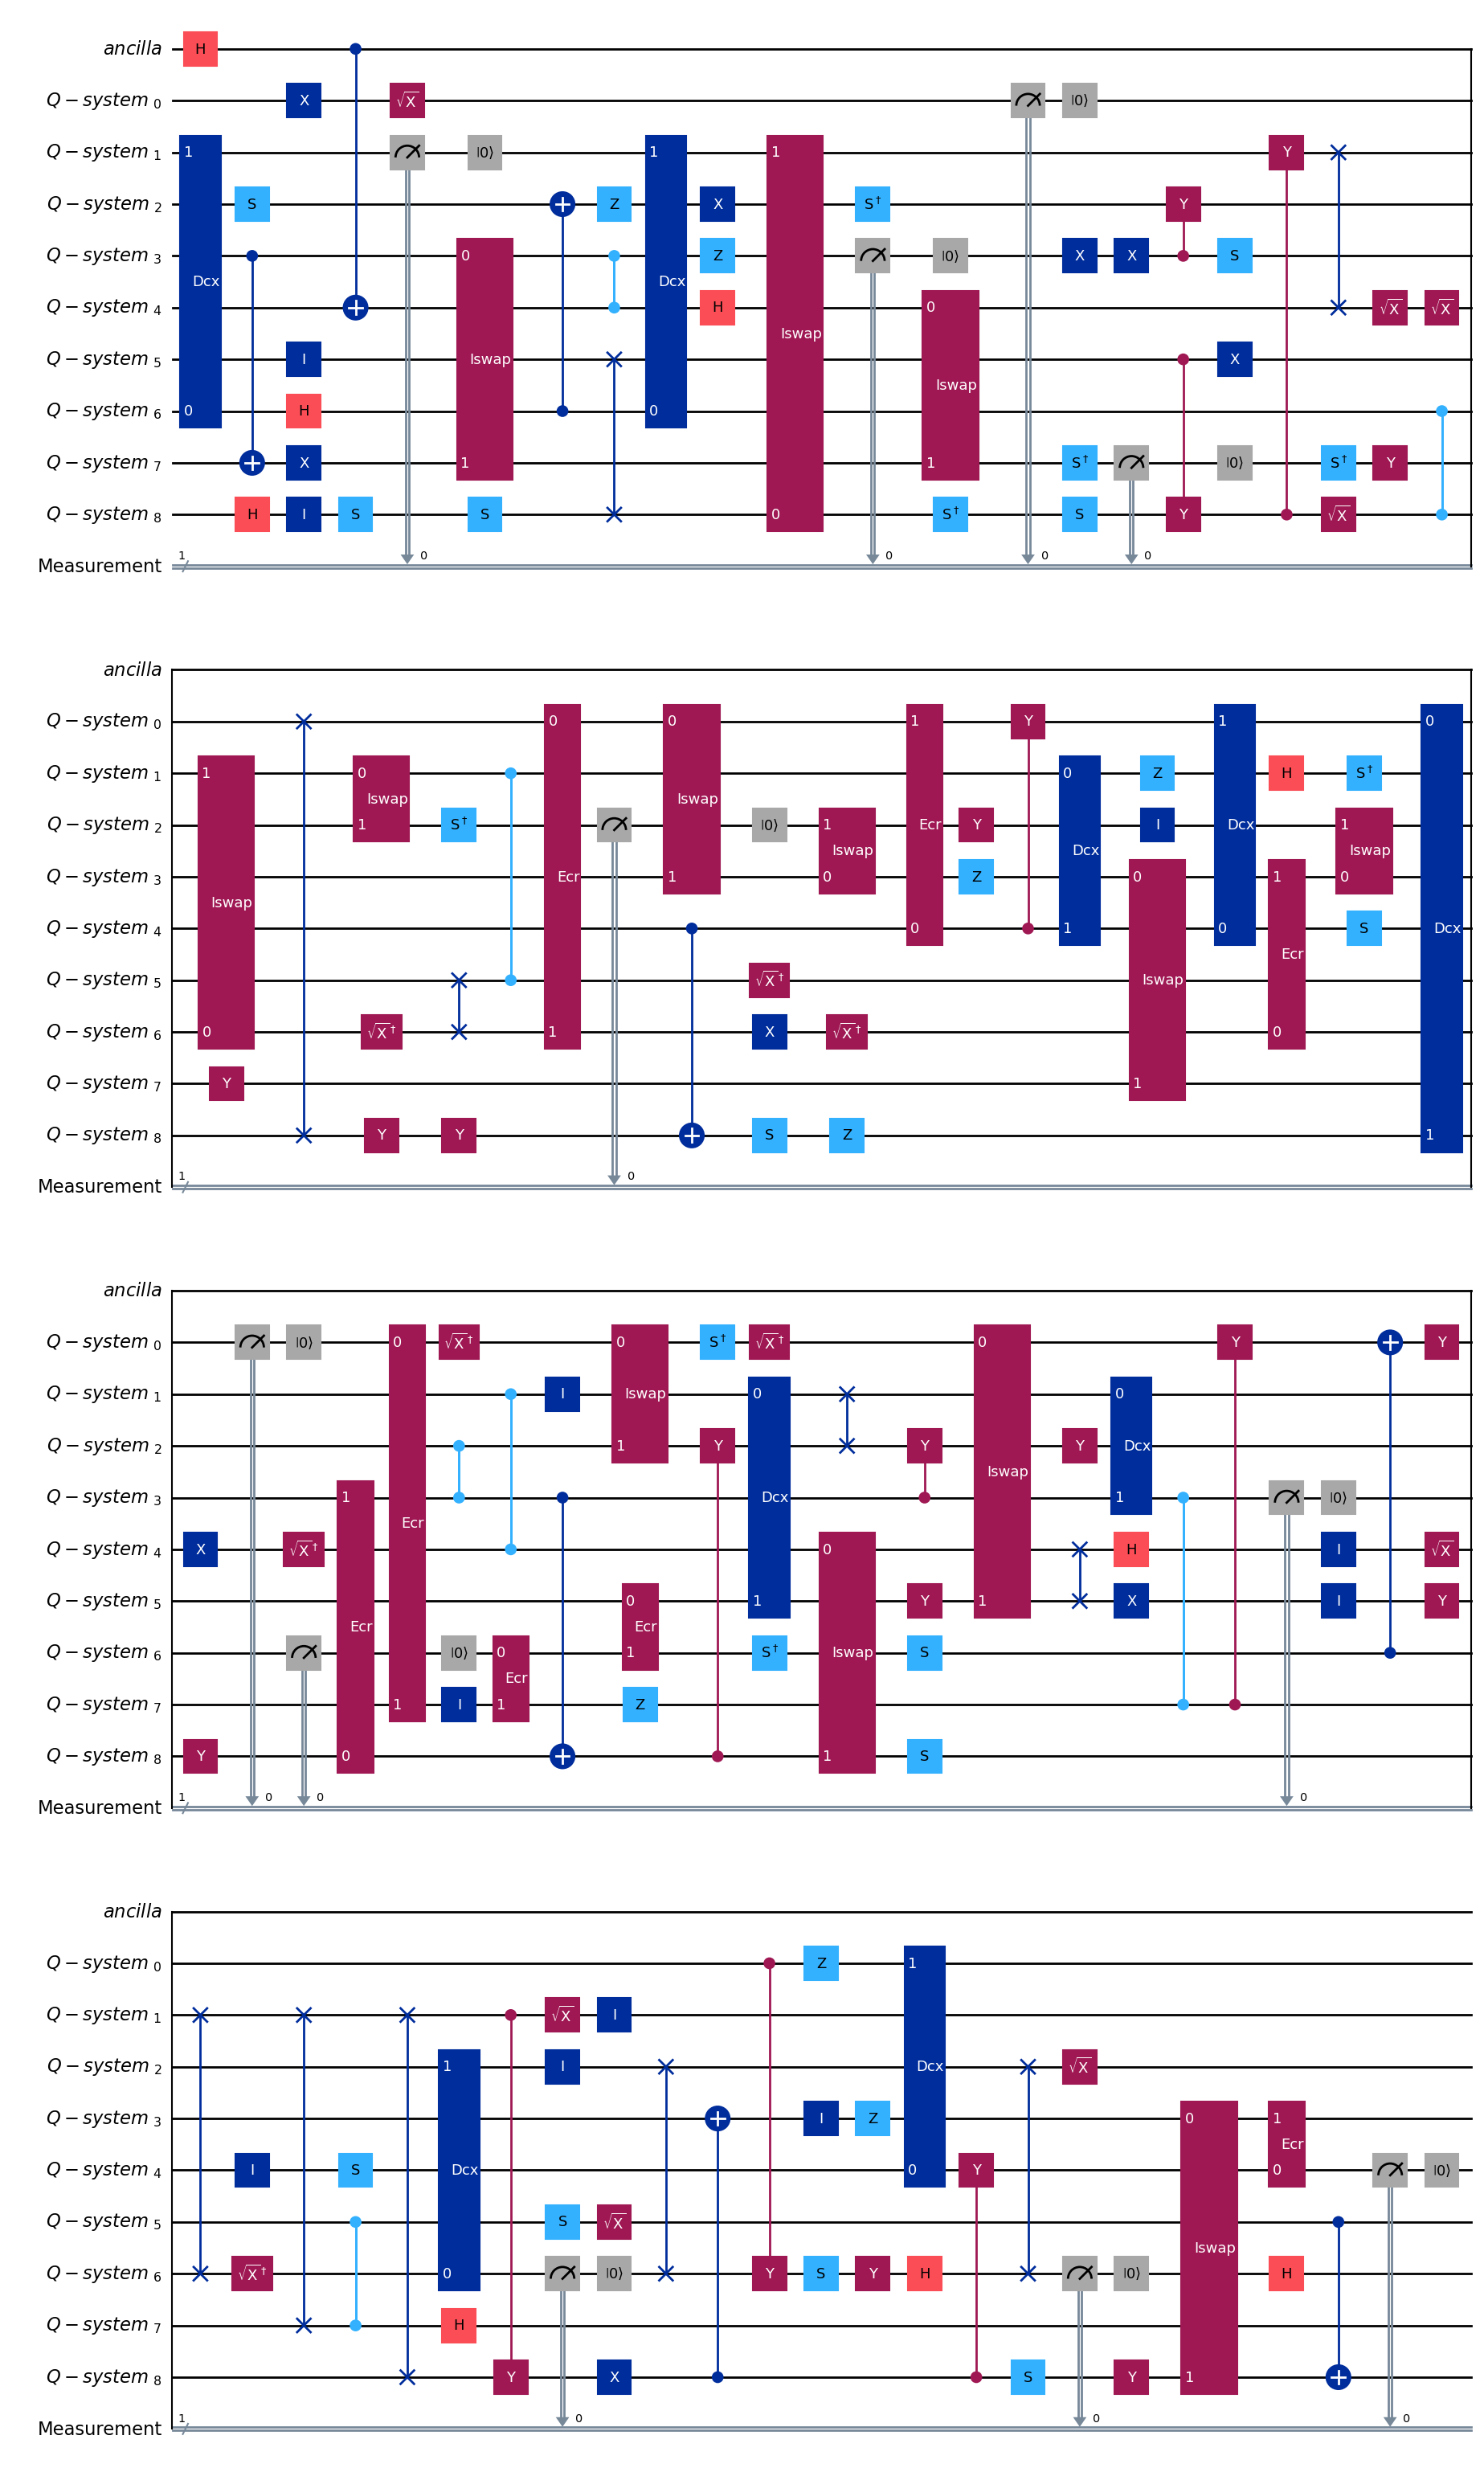

In [ ]:
import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Clifford
from qiskit.quantum_info import partial_trace, entropy, Statevector, purity, DensityMatrix
from qiskit.circuit.random import random_clifford_circuit
from qiskit_aer import AerSimulator
from qiskit import transpile


p_measure=0.6
T=15 #circuit depth

outcome = []
entropy_history = []
entropy_history_circ = []

rng = np.random.default_rng()
sim = AerSimulator(method='density_matrix')

#qc = QuantumCircuit(size,1)
# defining symbolic measurement gate
#measurement_gate = QuantumCircuit(1)
#measurement_gate.id(0)
#meas_gate = measurement_gate.to_gate(label='⟨ψ∣Z∣ψ⟩')

# Algorithm loop
for t in range(T):

    qc = random_clifford_circuit(num_qubits=size, num_gates=10)
    # gate = rng.choice(["H","S", "Z", "-S", "CX"])

    # if gate=="H":
    #     n = rng.integers(size)
    #     qc.h(n)
    #     qc.barrier([n])

    # elif gate=="S":
    #     n = rng.integers(size)
    #     qc.s(n)
    #     qc.barrier([n])

    # elif gate=="Z":
    #     n = rng.integers(size)
    #     qc.z(n)
    #     qc.barrier([n])

    # elif gate=="-S":
    #     n = rng.integers(size)
    #     qc.sdg(n)
    #     qc.barrier([n])

    # else:
    #     q1,q2 = rng.choice(size,2,replace=False)
    #     qc.cx(q1,q2)
    #     qc.barrier([q1,q2])

    qc_base = qc_base.compose(qc, qubits=System)

    state = state.evolve(Clifford(qc), qargs=list(range(1, size + 1)))

    #print(state == StabilizerState(qc_base)) # Temporary code to check if they match

    qc.clear()

    # Measuremnt part
    random = rng.random()
    if random < p_measure:
        q = rng.integers(1, size)

        # Circuite representation
        qc_base.measure(q, Measure[0])
        qc_base.reset(q)
        #qc.barrier([q])
        #qc_base = qc_base.compose(qc, qubits=System)
        #qc.clear()

        # Clifford representation
        outcom, state = state.measure([q]) #stabilizer method
        outcome.append(outcom)
        print(state)
        print(f"Measured system_{q} -> outcome {outcom}")

    # Circuite representation
    qc_sim = qc_base.copy()
    qc_sim.save_density_matrix()
    tqc = transpile(qc_sim, sim)
    result = sim.run(tqc, shots=1).result()
    rho_full = result.data(0)['density_matrix']
    rho_ancilla_circ = partial_trace(rho_full, list(range(1, size + 1)))
    S_circ = entropy(rho_ancilla_circ)
    print(f"Aer: {S_circ:.2f}")
    entropy_history_circ.append(S_circ)

    # Clifford representation
    rho_ancilla_stab = partial_trace(Statevector(state.clifford.to_circuit()), list(range(1, size + 1)))
    S = entropy(rho_ancilla_stab)
    entropy_history.append(S)  # <-- save it
    print(f"t={t}, S0={S:.2f}, purity={purity(rho_ancilla_stab).real:.2f}")

display(qc_base.draw('mpl'))

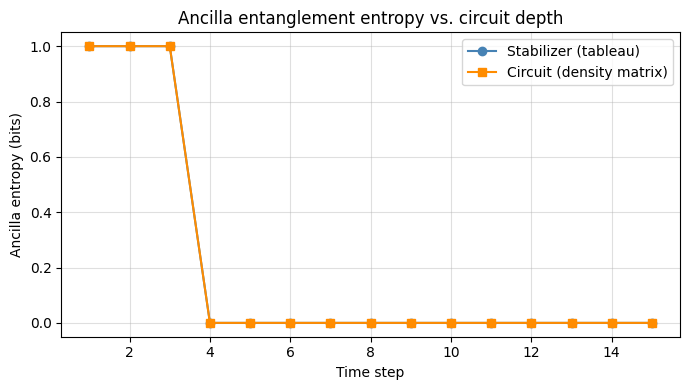

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, T + 1), entropy_history, marker='o', linewidth=1.5, color='steelblue', label='Stabilizer (tableau)')
plt.plot(range(1, T + 1), entropy_history_circ, marker='s', linewidth=1.5, color='darkorange', label='Circuit (density matrix)')
plt.xlabel("Time step")
plt.ylabel("Ancilla entropy (bits)")
plt.title("Ancilla entanglement entropy vs. circuit depth")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

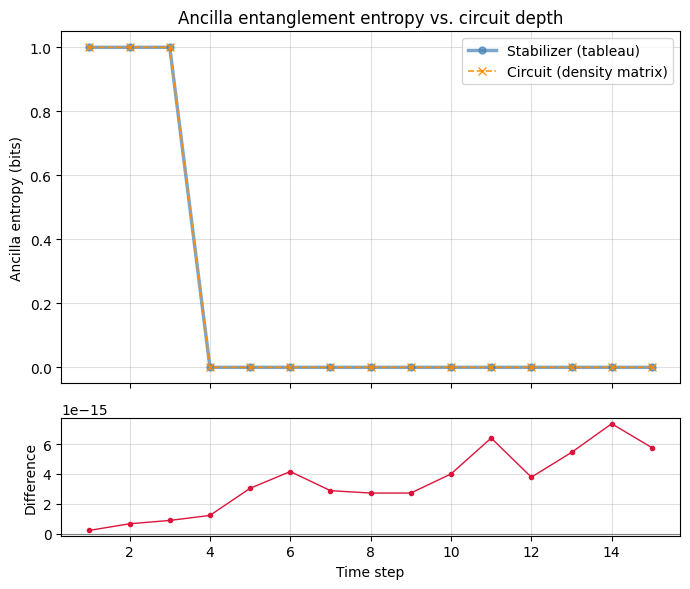

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]})

# Top: both series, styled to stay visible when overlapping
ax1.plot(range(1, T + 1), entropy_history, marker='o', markersize=5,
          linewidth=2.5, color='steelblue', alpha=0.7, label='Stabilizer (tableau)')
ax1.plot(range(1, T + 1), entropy_history_circ, marker='x', markersize=6,
          linewidth=1.2, linestyle='--', color='darkorange', alpha=0.9, label='Circuit (density matrix)')
ax1.set_ylabel("Ancilla entropy (bits)")
ax1.set_title("Ancilla entanglement entropy vs. circuit depth")
ax1.legend()
ax1.grid(True, alpha=0.4)

# Bottom: difference between the two, to show how close they really are
diff = np.array(entropy_history) - np.array(entropy_history_circ)
ax2.plot(range(1, T + 1), diff, marker='.', color='crimson', linewidth=1)
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.set_xlabel("Time step")
ax2.set_ylabel("Difference")
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

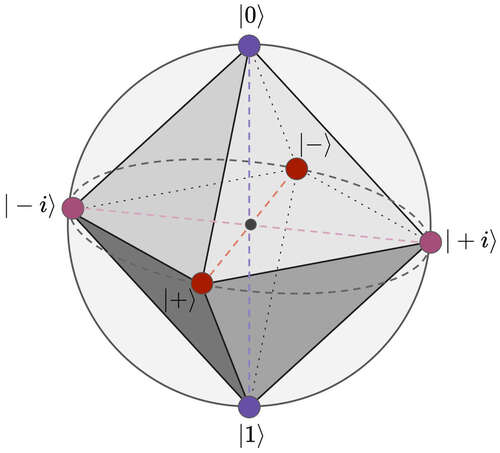

**The octahedron in the Bloch sphere defines the states accessible via single-qubit Clifford gates.**

$ZZZZ$ stabilizes $|0000\rangle$. So it's on of the $|0000\rangle$'s **stabilizers**. But it's not a **generator** of $|000\rangle$, because it's the product $Z_1 \cdot Z_2 \cdot Z_3 \cdot Z_4$ which is redundant and not independent.

Three simple conditions for a set to count as generators of an n-qubit state:

1. **They're real stabilizers.** Each one has to actually stabilize the state (give +1 when applied).

2. **None is redundant.** You can't build any one of them by multiplying the others together. Each one adds something new.

3. **There are exactly n of them.** For n qubits, you need exactly n generators — no more, no less.

That's it. Also worth knowing: the generator set isn't unique. For $|00\rangle$, $\{Z_1, Z_2\}$ works, but so does $\{Z_1, Z_1Z_2\}$ — different lists, same state, both valid.

**To turn the clifford tableau into a state vector, we need a circuit intermediary**

## problems

Good news: the core idea (couple an ancilla to the system with a Bell pair, then track how much the ancilla purifies as you evolve+measure the system) is the same in both. But there are several structural differences between your toy code and their actual procedure that matter for reproducing the physics — not just the trajectory-averaging point from before.

**1. Their gates are brickwork nearest-neighbor 2-qubit unitaries; yours are not.**

In `QCliffordAncilla`, each timestep does:
```julia
for j=1+t%2:2:2*L
    tempRandU = randu2(...)          # a random 2-qubit Clifford
    apply!(state, tempRandU, [j, j%(2*L)+1])
end
```
This is a genuine brickwork layer: every other timestep shifts by one qubit (even/odd staggering), each gate acts on a fixed nearest-neighbor pair, and every qubit gets touched exactly once per layer. This local, layered structure is what gives you the ballistic entanglement spreading (light cone) that produces the MIPT.

Your `random_clifford_circuit(num_qubits=size, num_gates=10)` instead draws 10 random Clifford gates that can act on arbitrary (not necessarily neighboring) qubits, with no brickwork/staggering structure. It's still "random Clifford dynamics," but it doesn't have the locality that the MIPT depends on, and the amount of scrambling per timestep isn't controlled the way it is in a proper brickwork layer. This is worth fixing if you want quantitatively correct behavior, not just a qualitatively-plausible curve.

**2. Their measurement is per-qubit, not one-qubit-per-timestep.**

```julia
for j in 1:2*L
    if Bool(x[j])        # x[j] ~ Bernoulli(p), independently for EACH qubit
        project!(state, single_z(2*L+1,j), ...)
    end
end
```
Every system qubit is measured independently with probability `p` each layer — so on average `p·(2L)` measurements happen per timestep, scaling with system size. Your code does:
```python
if random < p_measure:
    q = rng.integers(1, size)
```
which measures **at most one** qubit total per timestep, regardless of system size. As your system grows, the effective measurement rate per qubit shrinks to almost nothing — this dilutes the measurement effect a lot compared to the paper's protocol, and is probably part of why your entropy curve looks like noise rather than a controlled decay. You want an inner loop over all system qubits, each independently measured with probability `p_measure`.

**3. They scramble first, then couple the ancilla — you couple immediately.**

Their sequence is: (a) run `TScramble = 4L` layers of brickwork evolution on the system alone with no ancilla involved, (b) measure the middle qubit and correct it back to a fixed reference state, (c) *then* Hadamard+CNOT the reference qubit onto that now-reset middle qubit, (d) begin the monitored dynamics. This ensures the ancilla is injected into an already-scrambled (volume-law, generic) state rather than a trivial product state — closer to the "steady-state" regime the phase diagram describes.

Your circuit couples the ancilla to the system at t=0 before any scrambling. That's a reasonable simplification for a toy model, but it means your early-time entropy dynamics reflect the transient build-up of the reference-system entanglement, not steady-state purification. If you want a cleaner comparison to the paper, add a pre-scrambling phase (system-only brickwork gates, no measurement, no ancilla) before entangling the ancilla.

**4. Bug carried over from before still applies:** you're only running one trajectory. Even fixing #1–3, you need to average `entropy_history` over many independent circuit/measurement realizations (their code literally does this via `Ncircuit` loops over `QCliffordAncilla` calls) to see the smooth purification curve; a single run will always look like a jagged step function between 0 and 1 bit.

Want me to rewrite `mipt_simulation.py` with a proper brickwork gate layer, per-qubit measurement, an optional scrambling phase, and trajectory averaging, matching this Julia reference more closely?

Here's the same explanation in simpler terms.

The main idea of your code and the paper is the same:

* Create an **ancilla** (extra helper qubit) that's entangled with the system.
* Let the system evolve while making random measurements.
* Watch how the ancilla's entanglement changes over time.

However, your simulation is different from the paper in four important ways.

---

## 1. Your gates are too random

**Paper:**
Every time step, neighboring qubits interact in a neat pattern.

Imagine qubits in a line:

```
Time 1:
1—2   3—4   5—6

Time 2:
 2—3   4—5   6—1
```

So:

* only neighboring qubits interact,
* every qubit interacts exactly once each time step,
* information spreads gradually like a wave.

This gradual spreading is essential for the measurement-induced phase transition.

**Your code:**
Each gate can connect almost any two qubits randomly.

Example:

```
1—5
2—7
3—4
6—8
```

Information "teleports" all over the system instead of spreading locally.

**Why it matters:**
The physics in the paper depends on information spreading locally, not instantly everywhere.

---

## 2. You measure too little

**Paper:**

Every qubit gets its own chance to be measured every time step.

For example, with 20 qubits and measurement probability

```
p = 0.2
```

then on average

```
20 × 0.2 = 4
```

qubits are measured each step.

---

**Your code:**

Each time step you do something like

```
With probability p:
    measure ONE random qubit
```

So even if you have 100 qubits, you're still measuring at most one.

That means measurements become weaker and weaker as the system gets larger.

**Why it matters:**
Measurements are what destroy entanglement. Measuring only one qubit isn't enough to reproduce the paper's results.

---

## 3. The paper lets the system mix first

The paper does this:

```
Start with system

↓

Run many random gates
(no ancilla yet)

↓

System becomes highly scrambled

↓

Add the ancilla

↓

Start measurements
```

Your code does

```
Start

↓

Immediately attach ancilla

↓

Start evolution
```

So your ancilla is watching a system that's still "organizing itself."

The paper instead adds the ancilla after the system already looks random.

**Why it matters:**
The paper studies how measurements affect an already-scrambled quantum state, not how entanglement first builds up.

---

## 4. You're only doing one experiment

Every run is random.

One run might look like

```
1.0
0.9
1.0
0.7
0.8
0.3
```

Another might look like

```
1.0
1.0
0.8
0.9
0.5
0.6
```

Both are normal.

The paper repeats the experiment many times:

```
Run 1
Run 2
Run 3
...
Run 100
```

Then averages them.

Instead of a noisy zig-zag, you get a smooth curve that shows the real trend.

---

## In short

To make your simulation closer to the paper, you should:

1. ✅ Use **nearest-neighbor brickwork gates** instead of completely random gate locations.
2. ✅ Give **every qubit** an independent chance of being measured each time step.
3. ✅ **Scramble the system first**, then attach the ancilla.
4. ✅ **Average many independent runs** instead of looking at just one random trajectory.

These four changes will make your simulation much more faithful to the protocol used in the paper and should produce results that resemble the published measurement-induced phase transition more closely.
